# Mini Project Notebook: Customer segmentation using clustering

## Dr. Prashanth Kannadaguli
### Founding Chief Research Architect & President
### Dhaarini AI-Tech Research Academy, Bengaluru, India

## Learning Objectives

At the end of the experiment, you will be able to :

* extract summary level insight from a given customer dataset.

* handle the missing data and identify the underlying pattern or structure of the data.

* create an unsupervised model that generates the optimum number of segments for the customer base

* identify customer segments based on the overall buying behaviour


## Dataset

The dataset chosen for this mini project is the Online Retail dataset. It is a transnational data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.

The dataset contains 541909 records, and each record is made up of 8 fields.

To know more about the dataset : [click here](https://archive.ics.uci.edu/ml/datasets/Online+Retail)

## Information

**Clustering** is the task of grouping together a set of objects so that the objects in the same cluster are more similar to each other than to objects in other clusters. Similarity is a measure that reflects the strength of the relationship between two data objects.

In the clustering calculation, K-Means is a very popular algorithm. In this analysis, this method is used to cluster the similar data items.

In Retail and E-Commerce (B2C), and more broadly in B2B, one of the key elements shaping the business strategy of a firm is understanding of customer behaviour. More specifically, understanding the customers based on different business metrics: how much they spend (revenue), how often they spend (frequency), are they new or existing customers, what are their favorite products, etc... Such understanding in turn helps direct marketing, sales, account management and product teams to support customers on a personalized level and improve the product offering.

Furthermore, segmenting customers into different categories based on similar/cyclical buying pattern over a period of 1 year helps the retail shops manage their inventory better, thereby lowering costs and raising revenues by placing the orders in sync with the buying cycles.

## Problem Statement

Perform customer segmentation for an Online Retail using an Unsupervised Clustering technique

### Import Required packages

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
%matplotlib inline

## Data Wrangling

## Load the data

In [9]:
# Load the data (keep Online_Retail.xlsx in the same folder as this notebook)
# Reading the Excel file takes about a minute
raw_df = pd.read_excel('Online Retail.xlsx')
print('Shape:', raw_df.shape)
raw_df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data Pre-processing

Explore the dataset by performing the following operations:

* There is a lot of redundant data. Identify such data and take appropriate action.

  **Hint:** refer to this [link](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop_duplicates.html)

* Most Invoices appear as normal transactions with positive quantity and prices, but there are some prefixed with "C" or "A" which denote different transaction types. Invoice starting with C represents cancelled order and A represents the Adjusted. Identify such data and take appropriate action.

  **Hint:** Check the negative values in Quantity column for all cancelled orders

* Handle the null values by dropping or filling with appropriate mean


* Some of the transactions based on the `StockCode` variable are not actually products, but representing the costs or fees regarding to the post or bank or other tansactions. Find such data and handle it accordingly.

  Hint:
    - The transaction with `'POST' 'PADS' 'M' 'DOT' 'C2' 'BANK CHARGES'` as their `StockCodes` are considered as irrelevant transactions.

* Identify the outliers in the UntiPrice and Quantity and handle them accordingly.

  **Hint:** [link](https://kanoki.org/2020/04/23/how-to-remove-outliers-in-python/)

* Create a DayOfWeek column using `InvoiceDate`, Hint: pd.to_datetime()

**Note:** Perform all the above operations using a function to reuse and apply the same for test data.

In [10]:
# Stock codes that are fees / postage / discounts rather than real products
NON_PRODUCT_CODES = ['POST', 'PADS', 'M', 'DOT', 'C2', 'BANK CHARGES',     # given in the hint
                     'D', 'S', 'B', 'CRUK', 'AMAZONFEE']                   # other discounts / samples / fees found in the data


def preprocess(data, bounds=None):
    """Clean the transactions. Pass the `bounds` returned for the training data to reuse the
    same outlier limits on new / test data. Returns (clean_df, bounds)."""
    df = data.copy()
    print('Rows at start                       :', len(df))

    # 1. Redundant data: exact duplicate rows
    df = df.drop_duplicates()
    print('After removing duplicates           :', len(df))

    # 2. Cancelled ('C') and adjusted ('A') invoices, and any non-positive quantity
    df['InvoiceNo'] = df['InvoiceNo'].astype(str)
    df = df[~df['InvoiceNo'].str.upper().str.startswith(('C', 'A'))]
    df = df[df['Quantity'] > 0]
    print('After removing cancelled/adjusted   :', len(df))

    # 3. Missing values: a customer segment needs a CustomerID, and an ID cannot be replaced by a mean,
    #    so these rows are dropped. Missing descriptions are filled with a label.
    df['Description'] = df['Description'].fillna('UNKNOWN')
    df = df.dropna(subset=['CustomerID'])
    df['CustomerID'] = df['CustomerID'].astype(int)
    print('After removing missing CustomerID   :', len(df))

    # 4. Non-product transactions (postage, bank charges, fees ...)
    df = df[~df['StockCode'].astype(str).str.upper().isin(NON_PRODUCT_CODES)]
    print('After removing non-product codes    :', len(df))

    # 5. Outliers in Quantity and UnitPrice (IQR rule with a factor of 3 = extreme outliers only)
    if bounds is None:
        bounds = {}
        for col in ['Quantity', 'UnitPrice']:
            q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
            iqr = q3 - q1
            bounds[col] = (q1 - 3 * iqr, q3 + 3 * iqr)
    for col, (low, high) in bounds.items():
        df = df[(df[col] >= low) & (df[col] <= high)]
    print('After removing outliers             :', len(df), '| bounds:', {k: tuple(round(x, 2) for x in v) for k, v in bounds.items()})

    # 6. Date features
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
    df['Month'] = df['InvoiceDate'].dt.month_name()
    return df.reset_index(drop=True), bounds


df, outlier_bounds = preprocess(raw_df)
df.head()

Rows at start                       : 541909
After removing duplicates           : 536641
After removing cancelled/adjusted   : 526051
After removing missing CustomerID   : 392732
After removing non-product codes    : 391183
After removing outliers             : 364456 | bounds: {'Quantity': (np.float64(-28.0), np.float64(42.0)), 'UnitPrice': (np.float64(-6.25), np.float64(11.25))}


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,DayOfWeek,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Wednesday,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Wednesday,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Wednesday,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Wednesday,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Wednesday,December


## Understanding new insights from the data

1.  Are there any free items in the data? How many are there?

2.  Find the number of transactions per country and visualize using an appropriate plot

3.  What is the ratio of customers who are repeat purchasers vs single-time purchasers? Visualize using an appropriate plot.

4. Plot heatmap showing unit price per month and day of the week

  **Hint:** Month name as index on Y-axis, Day of the week on X-axis

5. Find the top 10 customers who bought the most no.of items. Also find the top 10 Items bought by most no.of customers.

In [11]:
# 1. Free items (UnitPrice == 0)
free_items = df[df['UnitPrice'] == 0]
print('Free item rows in the cleaned data :', len(free_items))
print('Free item rows in the raw data     :', (raw_df['UnitPrice'] == 0).sum())
print('Distinct products given free       :', free_items['StockCode'].nunique())
free_items[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'CustomerID', 'Country']].head()

Free item rows in the cleaned data : 25
Free item rows in the raw data     : 2515
Distinct products given free       : 25


,InvoiceNo,StockCode,Description,Quantity,CustomerID,Country
6311,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,12647,Germany
20711,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,16560,United Kingdom
23265,539722,22423,REGENCY CAKESTAND 3 TIER,10,14911,EIRE
26546,540372,22090,PAPER BUNTING RETROSPOT,24,13081,United Kingdom
26548,540372,22553,PLASTERS IN TIN SKULLS,24,13081,United Kingdom


Country
United Kingdom    15548
Germany             437
France              366
EIRE                245
Belgium              96
Spain                84
Netherlands          75
Portugal             48
Australia            45
Switzerland          44
Name: InvoiceNo, dtype: int64


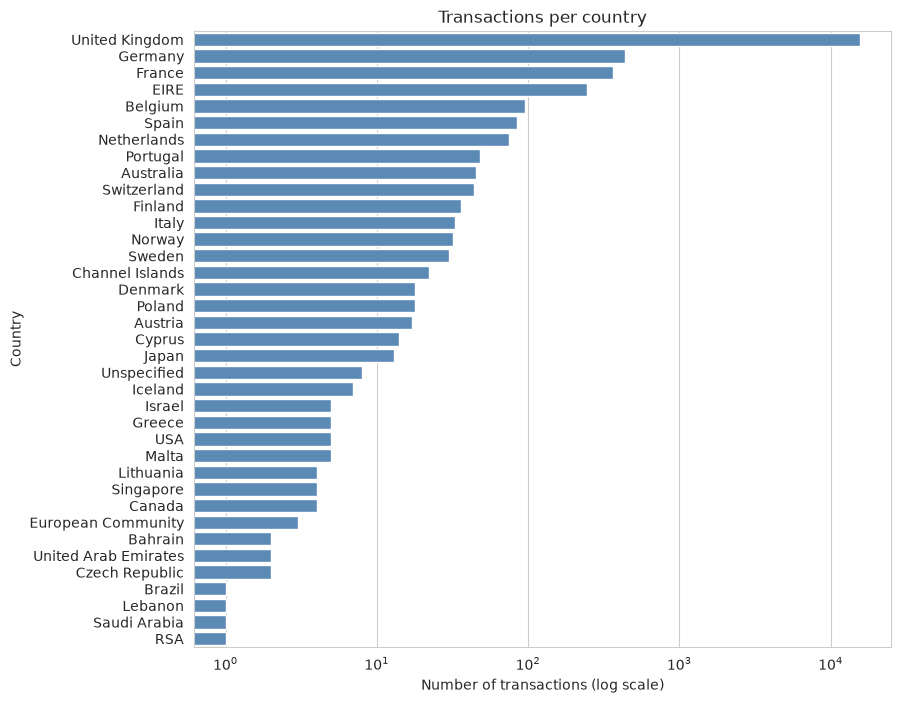

In [12]:
# 2. Number of transactions (unique invoices) per country
trans_country = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False)
print(trans_country.head(10))

plt.figure(figsize=(9, 8))
sns.barplot(x=trans_country.values, y=trans_country.index, color='#4c8bc4')
plt.xscale('log')            # the UK is so large that a linear axis would hide every other country
plt.xlabel('Number of transactions (log scale)')
plt.title('Transactions per country')
plt.show()

Repeat purchasers         2745
Single-time purchasers    1483
Name: count, dtype: int64
Repeat : single ratio = 1.85 : 1


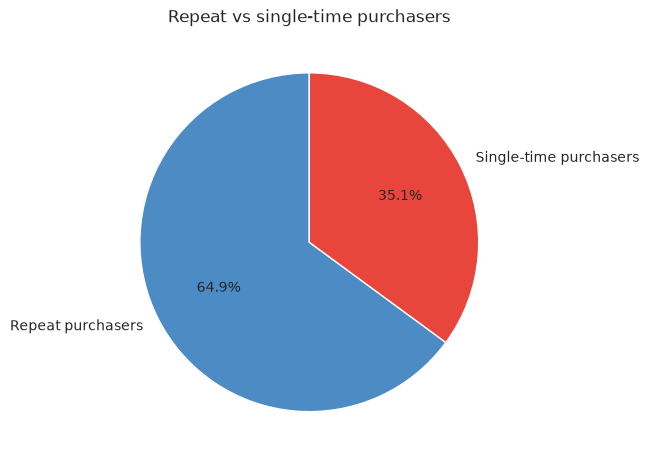

In [13]:
# 3. Repeat vs single-time purchasers
orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()
customer_type = np.where(orders_per_customer > 1, 'Repeat purchasers', 'Single-time purchasers')
type_counts = pd.Series(customer_type).value_counts()
print(type_counts)
print('Repeat : single ratio = %.2f : 1' % (type_counts['Repeat purchasers'] / type_counts['Single-time purchasers']))

plt.figure(figsize=(5.5, 5.5))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['#4c8bc4', '#e8453c'], wedgeprops={'edgecolor': 'white'})
plt.title('Repeat vs single-time purchasers')
plt.show()

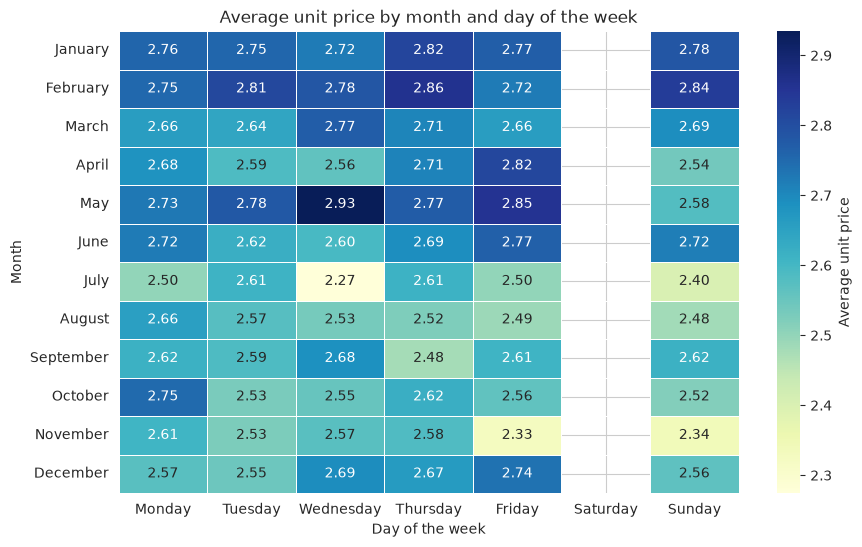

Days with no transactions at all: ['Saturday']


In [21]:
# 4. Heatmap of average unit price per month (Y) and day of the week (X)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

price_pivot = df.pivot_table(index='Month', columns='DayOfWeek', values='UnitPrice', aggfunc='mean')
price_pivot = price_pivot.reindex(index=month_order, columns=day_order)

plt.figure(figsize=(10, 6))
sns.heatmap(price_pivot, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5,
            cbar_kws={'label': 'Average unit price'})
plt.title('Average unit price by month and day of the week')
plt.xlabel('Day of the week'); plt.ylabel('Month')
plt.show()
print('Days with no transactions at all:', [d for d in day_order if d not in df['DayOfWeek'].unique()])

CustomerID
14911    55223
14298    23782
13089    23546
17841    20482
12748    16768
14096    14816
13081    14110
15311    10458
15159    10162
14156     9609
Name: Quantity, dtype: int64

StockCode  Description                       
85123A     WHITE HANGING HEART T-LIGHT HOLDER    841
47566      PARTY BUNTING                         674
84879      ASSORTED COLOUR BIRD ORNAMENT         652
22720      SET OF 3 CAKE TINS PANTRY DESIGN      636
22086      PAPER CHAIN KIT 50'S CHRISTMAS        603
21212      PACK OF 72 RETROSPOT CAKE CASES       597
85099B     JUMBO BAG RED RETROSPOT               592
22138      BAKING SET 9 PIECE RETROSPOT          577
22457      NATURAL SLATE HEART CHALKBOARD        576
22960      JAM MAKING SET WITH JARS              570
Name: CustomerID, dtype: int64


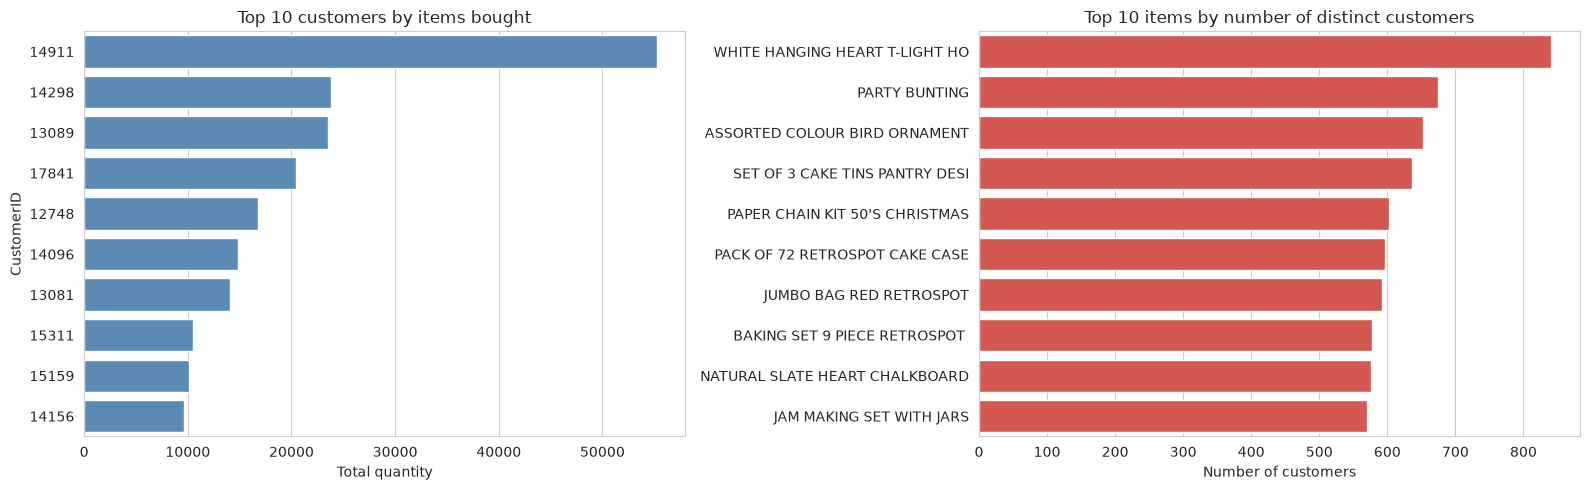

In [15]:
# 5a. Top 10 customers by number of items bought
top_customers = (df.groupby('CustomerID')['Quantity'].sum()
                   .sort_values(ascending=False).head(10))
print(top_customers)

# 5b. Top 10 items bought by the most customers
top_items = (df.groupby(['StockCode', 'Description'])['CustomerID'].nunique()
               .sort_values(ascending=False).head(10))
print()
print(top_items)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), color='#4c8bc4', ax=axes[0])
axes[0].set_title('Top 10 customers by items bought'); axes[0].set_xlabel('Total quantity'); axes[0].set_ylabel('CustomerID')
sns.barplot(x=top_items.values, y=[d[:30] for _, d in top_items.index], color='#e8453c', ax=axes[1])
axes[1].set_title('Top 10 items by number of distinct customers'); axes[1].set_xlabel('Number of customers'); axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## Feature Engineering and Transformation

### Create new features to uncover better insights and drop the unwanted columns

* Create a new column which represents Total amount spent by each customer

    **Hint:** Quantity * UnitPrice

* Customer IDs are seen to be repeated. Maintain unique customer IDs by grouping and summing up all possible observations per customer.

    **Hint:** [pandas.groupby.agg](https://pandas.pydata.org/pandas-docs/version/0.22/generated/pandas.core.groupby.DataFrameGroupBy.agg.html)

**Note:** Perform the above operations in function, to reuse and apply the same for test data

In [16]:
def engineer_features(data, reference_date=None):
    """One row per customer: all observations of a customer are grouped and summed up."""
    d = data.copy()
    d['TotalAmount'] = d['Quantity'] * d['UnitPrice']          # amount spent on each line
    if reference_date is None:
        reference_date = d['InvoiceDate'].max() + pd.Timedelta(days=1)

    customers = d.groupby('CustomerID').agg(
        Recency=('InvoiceDate', lambda s: (reference_date - s.max()).days),   # days since last purchase
        Frequency=('InvoiceNo', 'nunique'),                                   # number of invoices
        TotalQuantity=('Quantity', 'sum'),                                    # items bought
        UniqueProducts=('StockCode', 'nunique'),                              # variety of products
        TotalAmount=('TotalAmount', 'sum'),                                   # total spent
    )
    return customers


customer_df = engineer_features(df)
print(customer_df.shape)
display(customer_df.describe().T.round(2))
customer_df.head()

(4228, 5)


,count,mean,std,min,25%,50%,75%,max
Recency,4228.0,92.65,100.28,1.0,18.00,51.00,143.25,374.00
Frequency,4228.0,4.09,7.19,1.0,1.00,2.00,4.00,201.00
TotalQuantity,4228.0,669.44,1427.95,1.0,128.00,304.00,752.00,55223.00
UniqueProducts,4228.0,59.61,81.65,1.0,15.00,35.00,75.25,1708.00
TotalAmount,4228.0,1250.43,2806.43,2.9,249.53,559.39,1342.46,104979.31


,Recency,Frequency,TotalQuantity,UniqueProducts,TotalAmount
CustomerID,,,,,
12347,2,7,2155,101,3783.23
12348,249,3,140,6,90.20
12349,19,1,623,68,1328.55
12350,310,1,196,16,294.40
12352,36,7,521,56,1321.99


### Scale the data

Apply `StandardScaler` on the features.

In [17]:
# The features are very right-skewed (a few customers buy a huge amount), so a log transform is applied
# before StandardScaler; otherwise k-means would produce a few tiny "big spender" clusters and one giant one.
features = ['Recency', 'Frequency', 'TotalQuantity', 'UniqueProducts', 'TotalAmount']
X_log = np.log1p(customer_df[features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled_df = pd.DataFrame(X_scaled, index=customer_df.index, columns=features)
print('Mean (should be ~0):', X_scaled_df.mean().round(3).tolist())
print('Std  (should be ~1):', X_scaled_df.std().round(3).tolist())
X_scaled_df.head()

Mean (should be ~0): [-0.0, 0.0, 0.0, -0.0, 0.0]
Std  (should be ~1): [1.0, 1.0, 1.0, 1.0, 1.0]


,Recency,Frequency,TotalQuantity,UniqueProducts,TotalAmount
CustomerID,,,,,
12347,-2.042059,1.126138,1.527018,0.981276,1.534916
12348,1.261926,0.086949,-0.607257,-1.423795,-1.504796
12349,-0.624860,-0.952240,0.556736,0.630384,0.681471
12350,1.425026,-0.952240,-0.345530,-0.627237,-0.545876
12352,-0.165300,1.126138,0.417060,0.458868,0.677435


## Clustering

### Apply k-means algorithm to identify a specific number of clusters


* Fit the k-means model

* Extract and store the cluster centroids

Below are the parameters for k-means, which are helpful

**n_clusters** is no. of clusters specified

**k-means++** is a random initialization method for centroids to avoid random initialisation trap

**max_iter** is max no of iterations defined when k-means is running

**n_init** is no. of times k-means will run with different initial centroids

[why-is-k-means-slower-than-random-initialization-k-means](https://stats.stackexchange.com/questions/185396/why-is-k-means-slower-than-random-initialization-k-means/185422)

In [18]:
# Fit k-means with an initial guess of 4 clusters and store the centroids
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(X_scaled)

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)
print('Centroids (scaled space):')
display(centroids.round(2))
print('Inertia:', round(kmeans.inertia_, 1))

Centroids (scaled space):


,Recency,Frequency,TotalQuantity,UniqueProducts,TotalAmount
0,0.35,-0.53,-0.25,-0.17,-0.30
1,0.71,-0.81,-1.33,-1.33,-1.27
2,-1.27,1.87,1.50,1.29,1.56
3,-0.41,0.45,0.62,0.62,0.61


Inertia: 6704.7


#### Find the optimal number of clusters (K) by using the [Elbow method](https://pythonprogramminglanguage.com/kmeans-elbow-method/).

Use the optimal no. of clusters and store the cluster centroids

Optimal K from the elbow: 5


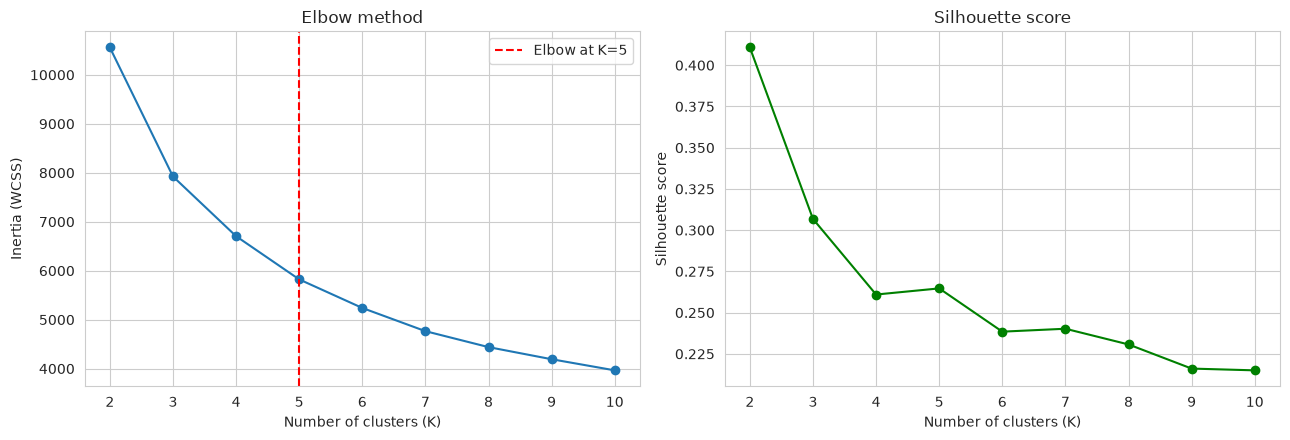


Final centroids (original units):


,Recency,Frequency,TotalQuantity,UniqueProducts,TotalAmount
Cluster 0,32.5,4.4,766.8,75.0,1372.0
Cluster 1,125.7,1.2,51.8,6.3,115.1
Cluster 2,130.3,1.6,225.3,27.3,411.4
Cluster 3,6.8,12.2,2094.0,143.6,3942.0
Cluster 4,13.7,2.1,219.3,26.1,396.7


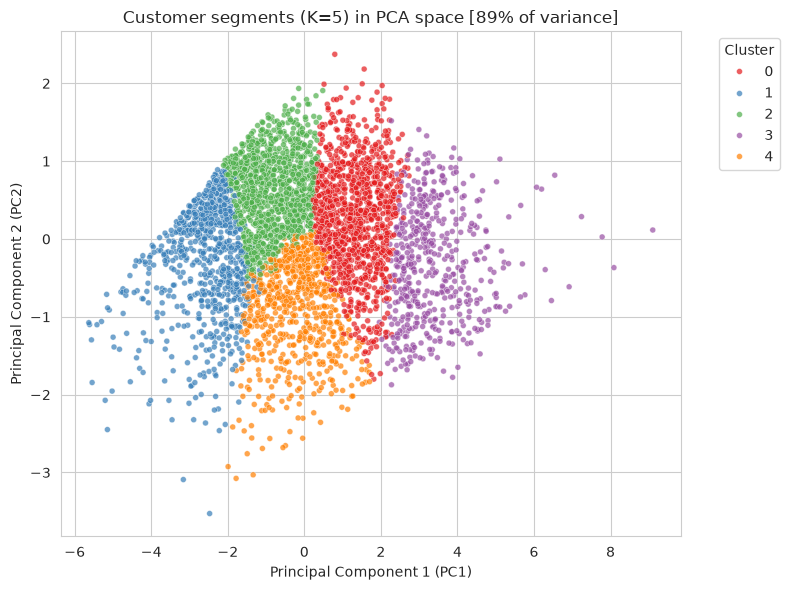


Cluster Profiles:


,Recency,Frequency,TotalQuantity,UniqueProducts,TotalAmount,Customers
Cluster,,,,,,
0,47.9,4.7,862.2,87.0,1538.8,1073
1,172.0,1.2,64.9,7.9,141.4,790
2,158.5,1.7,259.0,31.9,468.7,1175
3,11.3,15.0,2686.3,181.1,5189.1,512
4,18.2,2.3,257.0,32.8,466.9,678


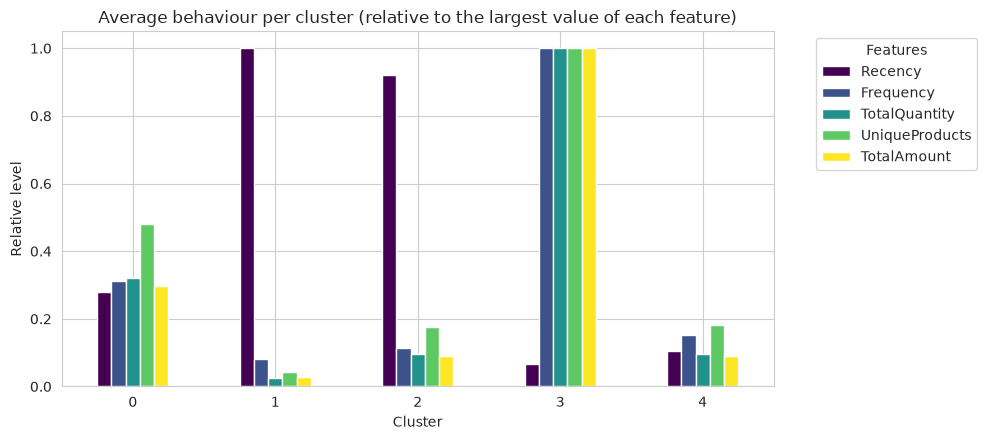

In [22]:
# --- 1. Elbow method & Silhouette Score ---
K_range = range(2, 11)
inertias, silhouettes = [], []

for k in K_range:
    # Fit KMeans
    km = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    
    # CRITICAL FIX: Add sample_size. Silhouette score is O(N^2). 
    # Without sampling, this will freeze on large datasets (300k+ rows).
    score = silhouette_score(X_scaled, km.labels_, sample_size=10000, random_state=42)
    silhouettes.append(score)

# Calculate the "elbow" mathematically (distance from the line y = -x + 1)
x = np.array(list(K_range), dtype=float)
y = np.array(inertias)

# Normalize to 0-1 scale to avoid scale bias
x_n = (x - x.min()) / (x.max() - x.min())
y_n = (y - y.min()) / (y.max() - y.min())

# Calculate perpendicular distance
dist = np.abs(x_n + y_n - 1) / np.sqrt(2)
optimal_k = int(x[np.argmax(dist)])
print(f'Optimal K from the elbow: {optimal_k}')

# Plotting metrics
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(K_range, inertias, 'o-')
axes[0].axvline(optimal_k, color='red', ls='--', label=f'Elbow at K={optimal_k}')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow method')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 'o-', color='green')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score')

plt.tight_layout()
plt.show()

# --- 2. Final model with the optimal K ---
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
final_kmeans.fit(X_scaled)
customer_df['Cluster'] = final_kmeans.labels_

# Centroids stored in the original units (undo StandardScaler, then log transform)
centroids_final = pd.DataFrame(
    np.expm1(scaler.inverse_transform(final_kmeans.cluster_centers_)),
    columns=features, 
    index=[f'Cluster {i}' for i in range(optimal_k)]
)

print('\nFinal centroids (original units):')
display(centroids_final.round(1))

# --- 3. Visualise the clusters in 2D with PCA ---
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_.sum()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=coords[:, 0], 
    y=coords[:, 1], 
    hue=customer_df['Cluster'], 
    palette='Set1' if optimal_k <= 9 else 'tab20', # Prevents tab10 limit errors
    s=18, 
    alpha=0.7
)
plt.title(f'Customer segments (K={optimal_k}) in PCA space [{explained_var:.0%} of variance]')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')

# Move legend outside the plot
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 4. Cluster profile: average behaviour per segment ---
profile = customer_df.groupby('Cluster')[features].mean().round(1)
profile['Customers'] = customer_df['Cluster'].value_counts().sort_index()

print('\nCluster Profiles:')
display(profile)

# Relative level bar plot
relative_profile = profile[features].div(profile[features].max())
relative_profile.plot(kind='bar', figsize=(10, 4.5), rot=0, colormap='viridis')

plt.title('Average behaviour per cluster (relative to the largest value of each feature)')
plt.ylabel('Relative level')
plt.xlabel('Cluster')

# Move legend outside the plot
plt.legend(title='Features', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Report Analysis

- Discuss the pros and cons of removing the missing values vs replacing with the mean values
- Based on the visualization of clusters, comment on the difference in buying patterns of each cluster
- What other methods could be used to determine the optimal no. of clusters?

## Answers

### 1. Removing missing values vs replacing them with the mean

**Removing (dropping) rows**
* *Pros:* no made-up data, so the remaining records are exactly what was observed; simple; and it is the only sensible choice for identifiers. In this dataset 135,080 rows (about 25%) have no `CustomerID`; a customer ID is a label, not a quantity, so a "mean ID" would invent a customer who does not exist and corrupt the per-customer grouping.
* *Cons:* information is lost (here a quarter of the transactions and all the sales to those anonymous buyers), the sample can become biased if the missing rows are not random (guest checkouts may behave differently from registered customers), and with many missing values a lot of data would be thrown away.

**Replacing with the mean (mean imputation)**
* *Pros:* keeps every row and the sample size, and works for numeric columns with only a few gaps.
* *Cons:* meaningless for IDs and text columns such as `Description`; it shrinks the variance and weakens correlations because many rows get the same value; and it can move points towards the centre, which distorts distance-based methods like k-means. It is also strongly affected by outliers (this data has extreme quantities and prices), so the median or a model-based imputation would be safer.

**Choice made here:** rows with a missing `CustomerID` were dropped (segments are built per customer), and the 1,454 missing `Description` values were filled with the label `UNKNOWN`.

### 2. Buying pattern of each cluster (K = 5)

| Cluster | Customers | Recency (days) | Orders | Items bought | Products | Total spent | Segment |
|---|---|---|---|---|---|---|---|
| 3 | 512 (12%) | 11 | 15.0 | 2,686 | 181 | about 5,189 | **Champions / VIP:** bought very recently, very often, in large baskets with a wide product range. A small group that gives a large share of revenue. |
| 0 | 1,073 (25%) | 48 | 4.7 | 862 | 87 | about 1,539 | **Loyal regulars:** several orders and good spend, but not as recent or frequent as the champions. |
| 4 | 678 (16%) | 18 | 2.3 | 257 | 33 | about 467 | **Recent, low-spend customers:** active in the last weeks but with few orders so far. Includes newer customers who can be grown. |
| 2 | 1,175 (28%) | 159 | 1.7 | 259 | 32 | about 469 | **At-risk / lapsing:** spend like cluster 4 but have not bought for about 5 months. Good target for win-back offers. |
| 1 | 790 (19%) | 172 | 1.2 | 65 | 8 | about 141 | **Lost / one-off small buyers:** a single small order, long ago. Low priority. |

Recency separates the active clusters (3, 0, 4) from the inactive ones (2, 1), while frequency, quantity and spend separate the big buyers (3, 0) from the small ones. Clusters 4 and 2 look alike in spending but differ completely in recency, which is a pattern a simple spend ranking would miss. Suggested actions: reward and retain cluster 3, upsell cluster 0 and 4, run reactivation campaigns for cluster 2, and spend little effort on cluster 1.

### 3. Other ways to choose the number of clusters
* **Silhouette score** (used above as a second check): how well each point fits its own cluster versus the nearest other one; higher is better. It was highest for K = 2, but that split is too coarse to be useful, and there is a small local peak at K = 5.
* **Gap statistic:** compares the within-cluster dispersion with that of random data and picks the K with the largest gap.
* **Calinski-Harabasz index** and **Davies-Bouldin index:** cluster separation vs compactness (higher CH and lower DB are better).
* **Dendrogram of hierarchical clustering:** cut where the vertical merge distances jump the most.
* **BIC / AIC with Gaussian Mixture Models:** choose the K with the best penalised likelihood.
* **Business judgement and stability:** the number of segments must be small enough for marketing to act on, and the clusters should stay similar when the data is resampled.